# Lab 3.1 — The operating model: turning pricing into money

*Prerequisite: every lab in stages 1, 2 and 4.*

Everything so far has been analysis. This notebook is about the part that
decides whether any of it reaches a customer.

Most pricing work dies in the last mile. Not because the maths was wrong —
because the recommendation arrived in the wrong format, at the wrong
meeting, without a plan for implementation, monitoring or the awkward
question about fairness. A mediocre analysis that gets implemented and
watched beats an excellent one that gets admired and shelved.

So: the KPIs that describe the business, the annual plan that commits it,
the governance that approves changes, the monitoring that catches them going
wrong, and a capstone case that puts the whole course together.

---

## The management pack

Start with what the business actually sees each month, and make sure the
numbers on it are the ones that drive decisions rather than the ones that
are easy to compute.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()

quotes = load("fct_quotes")
transactions = load("fct_transactions")
sites = load("dim_sites")
products = load("dim_products")
answer_key = truth()

CENTRAL_OVERHEAD_MONTH = 12000

transactions["year"] = transactions["date"].dt.year
quotes["year"] = quotes["date"].dt.year

pack = []
for year in [2023, 2024, 2025]:
    t = transactions[transactions["year"] == year]
    q = quotes[quotes["year"] == year]
    fixed = sites["fixed_cost_month_gbp"].sum() * 12 + CENTRAL_OVERHEAD_MONTH * 12
    pack.append({
        "year": year,
        "quotes": len(q),
        "orders": len(t),
        "conversion": len(t) / len(q),
        "turnover": t["order_value_gbp"].sum(),
        "gross revenue": t["gross_revenue_gbp"].sum(),
        "realised margin pp": (t["order_value_gbp"] * t["margin_pp"]).sum() / t["order_value_gbp"].sum(),
        "variable cost": t["variable_cost_gbp"].sum(),
        "contribution": t["contribution_gbp"].sum(),
        "fixed cost": fixed,
        "operating profit": t["contribution_gbp"].sum() - fixed,
        "contribution per quote": t["contribution_gbp"].sum() / len(q),
    })

pnl = pd.DataFrame(pack).set_index("year").T
pnl["change 24-25"] = pnl[2025] - pnl[2024]


def show(row):
    if row.name in ("conversion", "realised margin pp", "contribution per quote"):
        return row.map(lambda v: f"{v:,.3f}")
    return row.map(lambda v: f"{v:,.0f}")


print(pnl.apply(show, axis=1).to_string())

year                          2023        2024        2025 change 24-25
quotes                     102,039     102,253     105,254        3,001
orders                      58,297      58,391      60,968        2,577
conversion                   0.571       0.571       0.579        0.008
turnover                27,909,270  27,908,200  29,176,460    1,268,260
gross revenue            1,032,122   1,038,242   1,057,115       18,873
realised margin pp           3.489       3.509       3.417       -0.092
variable cost              433,381     433,425     444,479       11,054
contribution               598,740     604,817     612,636        7,819
fixed cost                 504,000     504,000     504,000            0
operating profit            94,740     100,817     108,636        7,819
contribution per quote       5.868       5.915       5.821       -0.094


### The KPI dictionary, and which ones are traps

| KPI | Definition | What it is good for | The trap |
|---|---|---|---|
| Turnover | Money customers handed over | Scale, market share | Not revenue. Ours is about 28× revenue |
| Gross revenue | What we earned on it | Top line | Ignores cost to serve |
| **Contribution** | Revenue − variable cost | **The pricing objective** | Not profit; fixed costs still to come |
| Operating profit | Contribution − fixed cost | The business | Not affected by *price* except through contribution |
| Realised margin (pp) | Turnover-weighted earned margin | The price level actually achieved | Mix moves it without any price decision |
| Conversion | Orders ÷ quotes | Demand-side diagnostic | Improves when you cut price. Never a target on its own |
| **Contribution per quote** | Contribution ÷ quotes | **The best single pricing metric** | Needs quote data, which many firms don't keep |
| AOV | Turnover ÷ orders | Mix and segment shifts | Rises when small customers leave — looks good, isn't |

The two in bold are the ones a pricing team should be measured on.
Contribution per quote is the sharpest: it moves when you price better and
does *not* move when the season is kind to you, because a busier month
raises the numerator and denominator together.

> **A rule for dashboards.** For every metric, ask: "if I halved the price
> tomorrow, which way would this go?" Any metric that improves is a
> diagnostic, not a target. Conversion, volume, turnover and market share
> all improve. Contribution per quote does not.

## The annual plan (AOP) and the price bridge

Once a year the business commits to a number. The pricing team's job is to
say how much of it comes from price, and to make that claim testable.

The format is a **bridge**: start from last year's actual, add each planned
effect, land on the plan. Every bar has an owner and a mechanism, and the
sum has to be arithmetic rather than ambition.

Let's build one from what this course has established:

| Action | Basis | Where it came from |
|---|---|---|
| Online +80bp (staged, two steps) | measured, then tested | [lab 2.4](../02_prove_the_change/lab_04_experiments_and_ab_testing.ipynb) and [lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) |
| Branches +25bp | modelled | [lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) |
| Airport kiosks −25bp | modelled — we are past the peak | [lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) |
| Stock fix at the tightest branches | recover censored demand | [lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb) |
| Underlying growth +3% | market | history |

In [2]:
model_data = quotes.copy()
model_data["log_order"] = np.log(model_data["order_value_gbp"] / 400)
model = smf.logit("converted ~ C(segment) * quoted_margin_pp + C(segment) * comp_best_margin_pp "
                  "+ season_z + log_order + loyalty_member + C(site_id)", data=model_data).fit(disp=0)

eta = np.asarray(model.predict(model_data, which="linear"))
margin_now = model_data["quoted_margin_pp"].to_numpy()
slope = np.full(len(model_data), model.params["quoted_margin_pp"])
for term, coefficient in model.params.items():
    if term.endswith(":quoted_margin_pp"):
        slope[(model_data["segment"] == term.split("[T.")[1].split("]")[0]).to_numpy()] += coefficient
context = eta - slope * margin_now

value = model_data["order_value_gbp"].to_numpy()
is_online = model_data["channel"].eq("online").to_numpy()
is_card = model_data["product_id"].eq("TRAVEL_CARD").to_numpy()
is_collect = model_data["fulfilment"].eq("click_collect").to_numpy()
is_delivery = model_data["fulfilment"].eq("delivery").to_numpy()

variable_cost = (value * model_data["funding_cost_bp"].to_numpy() / 10000
                 + value * np.where(is_online, 0.009, 0.002)
                 + model_data["product_id"].map(products.set_index("product_id")["handling_cost_gbp"]).to_numpy()
                 + 0.90 * is_collect
                 + np.where(is_delivery & ~is_card, 4.50, 0.0)
                 + value * np.where(~is_online, 0.0055, np.where(is_collect, 0.0028, 0.0)))
fixed_money = (model_data["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy()
               * is_card - variable_cost)

this_year = (model_data["year"] == 2025).to_numpy()


def contribution(margins, mask):
    p = 1 / (1 + np.exp(-(context + slope * margins)))
    return (p * (value * margins / 100 + fixed_money))[mask].sum()


move = np.zeros(len(model_data))
move[is_online] = 0.80
move[(model_data["channel"] == "branch").to_numpy()] = 0.25
move[(model_data["channel"] == "airport").to_numpy()] = -0.25

baseline = contribution(margin_now, this_year)
after_price = contribution(margin_now + move, this_year)

stock_recovery = (answer_key["stockouts"]["true_orders_refused"]
                  * transactions["contribution_gbp"].mean() / 3)          # notebook 10, per year
growth = 0.03 * after_price

bridge = pd.Series({
    "2025 actual contribution": baseline,
    "price actions": after_price - baseline,
    "stock availability fix": stock_recovery,
    "underlying growth": growth,
})
bridge["2026 plan"] = bridge[:4].sum()
print(bridge.round(0).to_string())
print(f"\nplanned contribution growth: {bridge['2026 plan'] / baseline - 1:.1%}")
print(f"of which price actions:      {(after_price - baseline) / baseline:.1%}")

2025 actual contribution    620652.0
price actions                61160.0
stock availability fix       11838.0
underlying growth            20454.0
2026 plan                   714105.0

planned contribution growth: 15.1%
of which price actions:      9.9%


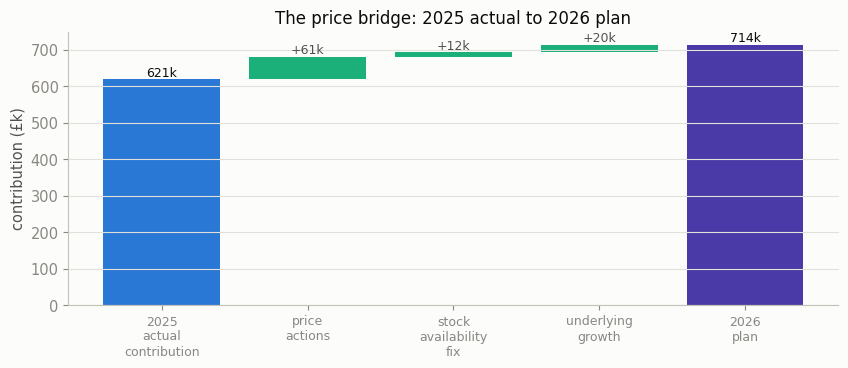

In [3]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))
labels = list(bridge.index)
running = 0.0
for i, (label, val) in enumerate(bridge.items()):
    if i == 0 or label == "2026 plan":
        ax.bar(i, val / 1000, color=PALETTE[0] if i == 0 else PALETTE[4])
        ax.text(i, val / 1000 + 8, f"{val / 1000:,.0f}k", ha="center", color=INK, fontsize=9)
        running = val / 1000
    else:
        ax.bar(i, val / 1000, bottom=running, color=PALETTE[1] if val > 0 else PALETTE[5])
        ax.text(i, running + val / 1000 + 8, f"+{val / 1000:,.0f}k", ha="center", color=SUB, fontsize=9)
        running += val / 1000

ax.set_xticks(range(len(labels)))
ax.set_xticklabels([l.replace(" ", "\n") for l in labels], fontsize=9)
ax.set_ylabel("contribution (£k)")
ax.set_title("The price bridge: 2025 actual to 2026 plan")
tidy(ax)
plt.tight_layout()
plt.show()

Three properties make a bridge like this survive a finance review.

**Every bar has a mechanism and an owner.** "Price actions" is not a wish;
it is three specific rate moves, each traceable to a measurement, each with
a named person who can implement it.

**The largest bar is the most tested one.** The online move rests on an
actual randomised experiment ([lab 2.4](../02_prove_the_change/lab_04_experiments_and_ab_testing.ipynb)) as well as the model. When
finance challenges the plan — and they will challenge the biggest number —
the answer is evidence rather than confidence.

**It is falsifiable.** Each bar implies a monthly trajectory you can check
against actuals. A plan that cannot be wrong until December is not a plan.

> **On staging.** The optimiser wanted online at +179bp. The plan says +80bp
> in two steps. That gap is deliberate: it keeps us inside the range the data
> supports, gives the market time to respond, and leaves the second half of
> the prize available if the first half behaves as predicted. Nobody is
> punished for a well-argued staged move; everyone remembers a 180bp move
> that went wrong.

## Governance: how a price change actually happens

| Question | Typical answer |
|---|---|
| Who *proposes* a price change? | Pricing / commercial analyst |
| Who *approves* it? | Pricing committee (commercial, finance, risk, compliance) |
| What is delegated? | Moves inside pre-agreed guardrails — e.g. ±25bp within a band |
| What escalates? | Anything outside guardrails, new fences, anything touching vulnerable customers |
| Who can stop it? | Compliance / risk, at any point |
| What is documented? | Rationale, evidence, expected impact, fair-value assessment, rollback plan |

### The one-page paper

Committees are short of time and long of scepticism. The format that works:

1. **The ask** — one sentence. *"Raise online euro and dollar rates by 40bp
   from 1 March, with a 10% holdout."*
2. **The money** — expected contribution, with a range. *"+£32k a year
   (£26k-£38k), measured in a randomised test, not modelled."*
3. **The evidence** — what you measured, how, and what would have changed
   your mind.
4. **The risks** — what could go wrong, how you would see it, what you would
   do. *"Competitor undercuts: we hold; the segment exposed is 34% of online
   volume."*
5. **Fair value** — who pays more, whether they can avoid it, and why it is
   reasonable.
6. **The rollback** — the trigger and the mechanism. *"If contribution per
   quote falls two consecutive weeks below the holdout, revert within 24
   hours."*

Six items. If you cannot fill in item 6, you are not ready to ask for item 1.

## Monitoring: what you watch after it goes live

A price change is not finished when it ships. Three layers:

**Daily — guardrails.** Did anything break? Rate board errors, negative
margins, prices outside the band, an unusual complaint rate. Automated,
alarmed, no interpretation required.

**Weekly — the decision metrics.** Contribution per quote versus the
holdout, conversion, competitor position. Interpreted by a person, compared
against what you predicted.

**Monthly — drift and structure.** Has the customer mix changed? Is the
model still calibrated? Has the competitor's behaviour changed shape?

The standard tool for the third is the **population stability index (PSI)**,
which compares the distribution of a variable now against a reference
period:

```
PSI = Σ (actual% − expected%) × ln(actual% / expected%)
```

Rules of thumb: **< 0.10** no material shift, **0.10–0.25** investigate,
**> 0.25** the model's world has changed — revalidate before trusting it.

In [4]:
def psi(expected, actual, bins=10):
    """Population stability index between two samples of a continuous variable."""
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    e = np.histogram(expected, bins=edges)[0] / len(expected)
    a = np.histogram(actual, bins=edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(((a - e) * np.log(a / e)).sum())


ref = quotes[quotes["year"] == 2024]
now = quotes[quotes["year"] == 2025]

print("population stability, 2025 vs 2024")
for label, column in [("order value", "order_value_gbp"),
                      ("our margin", "quoted_margin_pp"),
                      ("competitor margin", "comp_best_margin_pp"),
                      ("season", "season_z")]:
    print(f"  {label:20s} PSI {psi(ref[column], now[column]):.4f}")

mix_ref = ref["segment"].value_counts(normalize=True)
mix_now = now["segment"].value_counts(normalize=True).reindex(mix_ref.index)
mix_psi = float(((mix_now - mix_ref) * np.log(mix_now / mix_ref)).sum())
print(f"  {'segment mix':20s} PSI {mix_psi:.4f}")

population stability, 2025 vs 2024
  order value          PSI 0.0001
  our margin           PSI 0.0422
  competitor margin    PSI 0.1956
  season               PSI 0.0002
  segment mix          PSI 0.0000


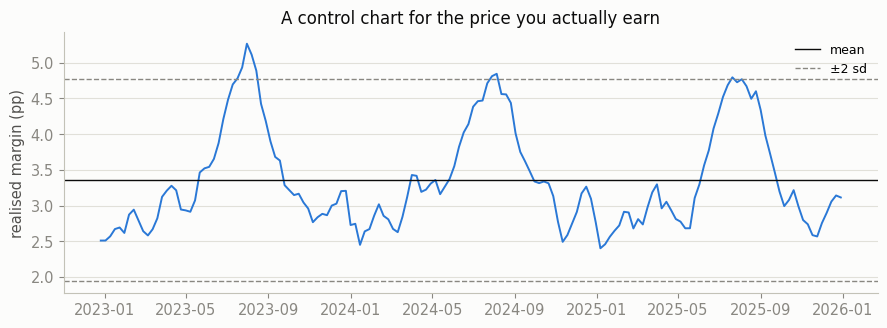

weeks outside ±2 sd: 8 of 158 (5%; about 5% is expected by chance alone)


In [5]:
weekly = (transactions.assign(week=transactions["date"].dt.to_period("W").dt.start_time)
          .groupby("week").apply(lambda g: pd.Series({
              "realised_margin": (g["order_value_gbp"] * g["margin_pp"]).sum() / g["order_value_gbp"].sum(),
              "contribution": g["contribution_gbp"].sum()}), include_groups=False))

mean, sd = weekly["realised_margin"].mean(), weekly["realised_margin"].std()

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(weekly.index, weekly["realised_margin"], color=PALETTE[0], lw=1.4)
for k, style_, label in [(0, "-", "mean"), (2, "--", "±2 sd"), (-2, "--", None)]:
    ax.axhline(mean + k * sd, color=MUT if k else INK, ls=style_, lw=1, label=label)
ax.set_ylabel("realised margin (pp)")
ax.set_title("A control chart for the price you actually earn")
ax.legend(fontsize=9)
tidy(ax)
plt.tight_layout()
plt.show()

breaches = weekly[(weekly["realised_margin"] - mean).abs() > 2 * sd]
print(f"weeks outside ±2 sd: {len(breaches)} of {len(weekly)} "
      f"({len(breaches) / len(weekly):.0%}; about 5% is expected by chance alone)")

The control chart is deliberately unsophisticated, and that is the point.
The failure mode it prevents is not a subtle one — it is *nobody looking*.
A weekly line with two limits and a named owner catches the pricing errors
that actually happen: a rate card that didn't refresh, a promotion that
never ended, a currency that fell out of the feed.

Note the honest footnote in the output: with ±2 standard deviations, about
5% of weeks breach by chance. An alert that fires every fortnight and means
nothing gets ignored within a month, and then the one that matters is
ignored too. **Tune alert thresholds to the response you actually want.**

## The operating cadence

| Frequency | What happens | Who |
|---|---|---|
| Daily | Rate board publishes; guardrail checks; competitor scrape | Pricing ops |
| Weekly | Decision metrics vs holdout; competitor review; exceptions | Pricing manager |
| Monthly | Management pack; PSI and calibration; test readouts | Pricing + finance |
| Quarterly | Fair-value assessment; segment review; model revalidation | Pricing + compliance |
| Annually | AOP and the price bridge; strategy review; guardrail reset | Everyone |

---

# Capstone

Everything in the course, on one case. Work through it before reading the
outline answer — the point is the reasoning, not the numbers.

> **The brief.** It is January 2026. The CFO has asked for £60,000 of extra
> contribution this year without a fall in customer numbers. AppRival has
> just announced it is expanding into airport locations. The Bristol branch
> lease is up for renewal in June. You have two analysts and one quarter.
>
> **Produce:** a one-page recommendation with a prioritised list of actions,
> the expected money for each, the evidence behind it, the risks, and what
> you would measure to know it is working.

**A checklist for your answer**

- [ ] Where is the money now? (contribution by site, per quote and in total)
- [ ] Which prices are furthest from their own optimum, and how confident are
      you in each?
- [ ] What can be *tested* rather than decided?
- [ ] What does the volume constraint cost, and did you price it?
- [ ] Who pays more under your proposal, and can they avoid it?
- [ ] What breaks if the competitor responds?
- [ ] What are your rollback triggers?

In [6]:
y25 = transactions[transactions["year"] == 2025]
channel_view = (y25.groupby("channel")
                .agg(orders=("txn_id", "count"), turnover=("order_value_gbp", "sum"),
                     contribution=("contribution_gbp", "sum")))
channel_view["quotes"] = quotes[quotes["year"] == 2025].groupby("channel").size()
channel_view["contribution per quote"] = channel_view["contribution"] / channel_view["quotes"]
channel_view["fixed"] = sites.groupby("channel")["fixed_cost_month_gbp"].sum() * 12
channel_view["channel profit"] = channel_view["contribution"] - channel_view["fixed"]
print("BY CHANNEL\n")
print(channel_view.round(1).to_string())

region_view = (y25[y25["region_id"] != "AIRPORT"].groupby("region_id")
               .agg(orders=("txn_id", "count"), contribution=("contribution_gbp", "sum")))
region_view["quotes"] = (quotes[(quotes["year"] == 2025) & (quotes["region_id"] != "AIRPORT")]
                         .groupby("region_id").size())
region_view["contribution per quote"] = region_view["contribution"] / region_view["quotes"]
print("\nBY REGION (the unit a geo test would randomise)\n")
print(region_view.round(2).to_string())
print("\nYour starting point. The rest of the capstone is yours - "
      "the tools are in notebooks 06 (test), 08 (optimise), 09 (fairness), 10 (competition).")

BY CHANNEL

         orders    turnover  contribution  quotes  contribution per quote   fixed  channel profit
channel                                                                                          
airport   12042   4204320.0      208882.9   19912                    10.5  108000        100882.9
branch    26746  13497800.0      305648.8   49122                     6.2  180000        125648.8
online    22180  11474340.0       98104.7   36220                     2.7   72000         26104.7

BY REGION (the unit a geo test would randomise)

           orders  contribution  quotes  contribution per quote
region_id                                                      
R01          4778      38836.91    8287                    4.69
R02          4708      39576.39    7920                    5.00
R03          3477      27961.10    6180                    4.52
R04          3926      33265.99    6754                    4.93
R05          4179      35250.91    7482                    4.71


<details>
<summary>Outline of a strong answer</summary>

**1. Online rate, staged. (~£27k, highest confidence)**
The randomised test in [lab 2.4](../02_prove_the_change/lab_04_experiments_and_ab_testing.ipynb) already showed +40bp raising contribution
per quote from £0.60 to £1.45 — an annualised £27k with a measured
confidence interval, not a modelled one. Implement it permanently with a 10%
holdout, then test the *next* 40bp. Risk: AppRival is the price leader
online and we follow them; if they cut, hold rather than match, because the
exposed segment is a minority of volume ([lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb)).

**2. Heathrow rate reduction. (~£3k, medium confidence, and it protects a
flank)**
The kiosk is priced past its own peak ([lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb)). With AppRival entering
airports, being 2pp above a new entrant is a bad place to defend from.
Cutting 40bp raises contribution *and* narrows the gap a new competitor
would advertise against. Pair it with a fair-value note: this reduces what
the most captive customers pay, which is the right direction of travel under
Consumer Duty.

**3. Stock availability at the tightest branches. (high confidence, and not
a price action at all)**
Thousands of orders and millions of pounds of turnover were refused for want
of notes across three years ([lab 1.4](../01_set_the_rate/lab_04_competition_and_dynamics.ipynb)). Increasing the delivery schedule
at the worst-affected branches recovers contribution with no price risk and
no customer detriment — and, because refused customers come back less often,
it protects next year's base as well.
It also fixes the censored data corrupting the forecast, which pays again
next year. *And it directly supports the "no fall in customer numbers"
constraint, which is what makes the price rises affordable.*

**4. Size-band fencing. (~£35k a year at full roll-out, medium confidence,
test first)**
[Lab 4.1](../04_satisfy_the_regulator/lab_01_segmentation_and_fairness.ipynb)'s observable fence — better rates above £600, keener at the
airport for small orders capped at policy — captures about a third of the
theoretical segmentation prize while remaining explainable and
self-selected. Test on one branch and online before rolling out.

**5. The weakest branches.** Any branch below break-even is a question about
*avoidable* fixed cost, not about price. Because the host network carries
the rent and staff, closing a counter saves very little — while the
commission it pays disappears with the volume. Decide on the P&L *after*
actions 3 and 4 land, not on last year's.

**Not recommended: a promotion.** [Lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb) showed the last one moved
contribution by roughly nothing while consuming a quarter of the
organisation's attention. If volume needs support, the stock fix delivers it
without giving away rate.

Together those four actions bridge to roughly the £60k the CFO asked for —
and the bridge above shows the price actions alone are worth £68k a year on
the model, before the stock fix. The order matters: the tested action first,
the availability fix (which supports the no-volume-loss constraint) second,
the modelled actions last and staged.

**Measurement plan.** Contribution per quote by site, weekly, against a
holdout where one exists. Conversion and competitor position as diagnostics.
Fair-value review of the fence before launch and 90 days after. Rollback
trigger: two consecutive weeks of contribution per quote below the holdout,
or any guardrail breach.

**What could make this wrong.** The elasticity underpinning actions 2 and 4
is modelled, not tested; if customers are 25% more sensitive than estimated,
those two deliver about a third less ([lab 1.3](../01_set_the_rate/lab_03_price_optimisation.ipynb)'s sensitivity analysis) —
still positive, which is why they are worth doing while the tests run.

</details>

---

## Where to go next

You have now done, at least once, every core task of a pricing role:
building the data, reading the economics, estimating demand honestly,
running and interpreting an experiment, optimising under constraints,
thinking about fairness, responding to competition, and turning it all into
a plan somebody can approve.

The natural next steps in this repository:

- [`../README.md`](../README.md) — the same
  material in prose, plus the glossary, the senior reference (strategy,
  channels, operating model, travel-money domain) and an interview question
  bank.
- [`../engine/README.md`](../engine/README.md)
  — a production-shaped version of this world, with pipelines and generated
  reports.
- [`../05_the_panel/README.md`](../05_the_panel/README.md) — one hard interview question
  per notebook: geo experiments, hierarchical elasticity, censored demand,
  competitor games, DML.

## Final self-test

If you can answer these without notes, the course has done its job.

1. Why do fixed costs not affect the optimal price — and what *do* they
   decide?
2. A colleague reports an elasticity of −2%/pp from a regression on two
   years of daily data. What is your first question?
3. Conversion fell 9pp in your price test. Should you stop the test?
4. Name the three conditions an instrument must satisfy, and say which one
   you can test.
5. Your model says the captive segment should pay three times the going
   rate. What do you do next?
6. What is the single number you would put on a pricing team's dashboard?

<details>
<summary>Answers</summary>

1. Because they are the same under every price, so they cancel from the
   maximisation. They decide whether the site, channel or product should
   exist at all — a different question, answered on avoidable cost.

2. "What did you control for?" −2%/pp is the signature of an uncontrolled
   estimate in a business that raises prices in peak season ([lab 1.2](../01_set_the_rate/lab_02_demand_and_elasticity.ipynb), [lab 2.3](../02_prove_the_change/lab_03_regression_for_pricing.ipynb) and [lab 2.5](../02_prove_the_change/lab_05_causal_inference.ipynb) — the truth here was −26%/pp). Second question: "what set the price
   in your data, and what were they looking at?"

3. No — not on that alone. Conversion is a diagnostic. Check contribution
   per quote, which in our test rose so much it more than doubled channel
   profitability. Stop a test for guardrail breaches, not for a metric
   moving in the direction price always moves it.

4. **Relevance** (it moves price — testable, first-stage F), **exclusion**
   (it affects the outcome only through price — not testable, an argument),
   and **independence** (as good as random given your controls). [Lab 2.5](../02_prove_the_change/lab_05_causal_inference.ipynb)
   showed an instrument that passed the testable one and failed the others.

5. Ask *why* they are insensitive. If the answer is "they value speed and
   have chosen convenience", it is a defensible fence. If the answer is
   "they cannot shop around", you are pricing vulnerability — price the cap
   instead, and present the cost of the cap as the deliberate decision it
   is.

6. **Contribution per quote** (or per enquiry, per session — whatever your
   unit of demand offered is). It is the only common metric that improves
   when you price better and does not improve when you simply cut price or
   have a good season.

</details>